# CodSoft ML Internship — Task 2: Credit Card Fraud Detection

**Task:** Build a model to detect fraudulent credit card transactions, experimenting with Logistic Regression, Decision Trees, and Random Forests.

**Dataset:** [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) (Kaggle, ULB Machine Learning Group) — 284,807 transactions, 492 fraud (~0.17%).

> Place `creditcard.csv` inside a `data/` folder next to this notebook before running.


## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load the Data

In [2]:
df = pd.read_csv("data/creditcard.csv")
print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Class Distribution

The dataset is heavily imbalanced, so this is checked upfront — it's why accuracy alone won't be a reliable metric later on.

Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.1727%


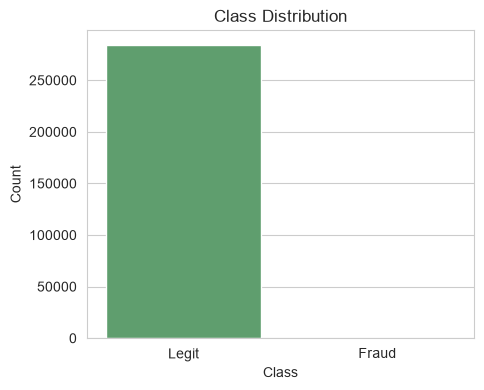

In [3]:
class_counts = df["Class"].value_counts()
print(class_counts)
print(f"Fraud rate: {class_counts[1] / len(df) * 100:.4f}%")

plt.figure(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index,
            palette=["#55A868", "#C44E52"], legend=False)
plt.xticks([0, 1], ["Legit", "Fraud"])
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

## 4. Preprocessing

`V1`-`V28` are already PCA-transformed. `Time` and `Amount` are on very different scales, so they're standardized before training.

In [4]:
scaler = StandardScaler()
df["scaled_amount"] = scaler.fit_transform(df[["Amount"]])
df["scaled_time"] = scaler.fit_transform(df[["Time"]])
df = df.drop(["Amount", "Time"], axis=1)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


## 5. Train/Test Split

In [5]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Train shape: (227845, 30) | Test shape: (56962, 30)


## 6. Train Models

`class_weight="balanced"` is used so each model penalizes missing the rare fraud class more heavily.

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1),
}

fitted_models = {}
f1_scores = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    fitted_models[name] = model
    preds = model.predict(X_test)
    f1_scores[name] = f1_score(y_test, preds)

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...


## 7. Evaluate

Precision/recall/F1 matter more than raw accuracy here, since predicting "legit" every time would already score ~99.8% accuracy.

In [7]:
for name, model in fitted_models.items():
    preds = model.predict(X_test)
    print(f"=== {name} ===")
    print(classification_report(y_test, preds, target_names=["Legit", "Fraud"]))
    print(f"F1 (fraud class): {f1_scores[name]:.4f}")
    print("-" * 60)

=== Logistic Regression ===
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

F1 (fraud class): 0.1141
------------------------------------------------------------
=== Decision Tree ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.71      0.71      0.71        98

    accuracy                           1.00     56962
   macro avg       0.85      0.86      0.86     56962
weighted avg       1.00      1.00      1.00     56962

F1 (fraud class): 0.7107
------------------------------------------------------------
=== Random Forest ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    

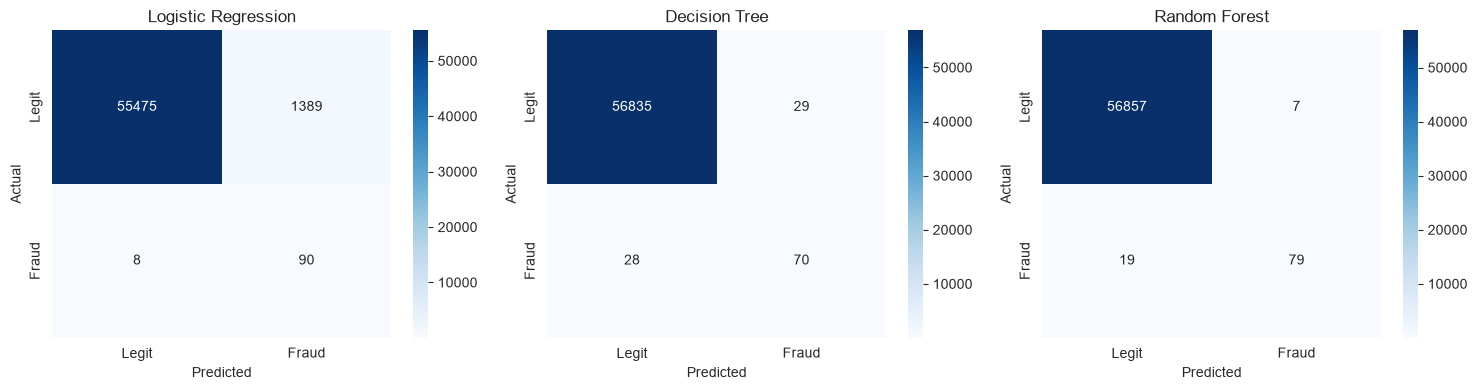

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, fitted_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

## 8. Best Model

In [9]:
best_name = max(f1_scores, key=f1_scores.get)
print("F1 scores:", f1_scores)
print(f"\nBest model: {best_name} (F1 = {f1_scores[best_name]:.4f})")

F1 scores: {'Logistic Regression': 0.11414077362079898, 'Decision Tree': 0.7106598984771574, 'Random Forest': 0.8586956521739131}

Best model: Random Forest (F1 = 0.8587)


## Conclusion

Logistic Regression, Decision Tree, and Random Forest were trained on scaled transaction data with `class_weight="balanced"` to account for the severe class imbalance (~0.17% fraud). Models were compared using precision, recall, and F1 on the fraud class rather than raw accuracy, since accuracy is misleading on this dataset.
